# Disease Prediction Model - Preparation and Preprocessing

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import arff

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
root = Path().resolve().parent

diabetes_path = root / "data" / "raw" / "diabetes_raw.csv"
df_diabetes = pd.read_csv(diabetes_path)

hypertension_path = root / "data" / "raw" / "hypertension_raw.csv"
df_hypertension = pd.read_csv(hypertension_path)

heart_disease_path = root / "data" / "raw" / "heart_disease_raw.csv"
df_heart_disease = pd.read_csv(heart_disease_path)

* Now all the datasets are loaded and they are all available in CSV format. This makes it easier to read both for myself and using pandas.

## 2. Data Cleaning

* Now we can begin with data cleaning. Since we have multiple datasets at play here for each disease, we can clean all datasets of each disease one by one. This will provide a good structure and also make it easier to merge diseases that have multiple datasets. All datasets will follow the below dataset cleaning pipeline:
    - Data inspection
    - Standardizing column names
    - Removing duplicates
    - Fixing data types
    - Handling missing values
    - Handling outliers
    - Final check and saving dataset

### 2.1 Diabetes dataset

Inspecting the dataset


In [3]:
df_diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


**"diabetes" is our target variable**

In [4]:
df_diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df_diabetes.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
df_diabetes.describe(include="all")

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000,100000.000000,100000.00000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,No Info,NaN,NaN,NaN,NaN
freq,58552,NaN,NaN,NaN,35816,NaN,NaN,NaN,NaN
mean,NaN,41.885856,0.07485,0.039420,NaN,27.320767,5.527507,138.058060,0.085000
std,NaN,22.516840,0.26315,0.194593,NaN,6.636783,1.070672,40.708136,0.278883
min,NaN,0.080000,0.00000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.00000,0.000000,NaN,23.630000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.00000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,60.000000,0.00000,0.000000,NaN,29.580000,6.200000,159.000000,0.000000


The above dataset already has a good structure. There aren't any glaring problems. Let's move on to the next step and standardize column names.

In [7]:
df_diabetes.columns = df_diabetes.columns.str.lower()
df_diabetes.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

Now we can check for and remove duplicates.

In [8]:
df_diabetes.duplicated().sum()

np.int64(3854)

In [9]:
df_diabetes = df_diabetes.drop_duplicates()
df_diabetes.duplicated().sum()

np.int64(0)

Duplicate values have been removed. Now we can move onto fixing data types.

Gender and smoking history are strings but they have almost binary values, just in the form of strings. Thus, converting them to category will make it much more efficient.

In [10]:
df_diabetes["gender"] = df_diabetes["gender"].astype("category")
df_diabetes["smoking_history"] = df_diabetes["smoking_history"].astype("category")

Age is a float when it should just be an int.

In [11]:
df_diabetes["age"] = df_diabetes["age"].astype(int)

We do not need to handle any missing values as there are none. We can directly move on to handling outliers.

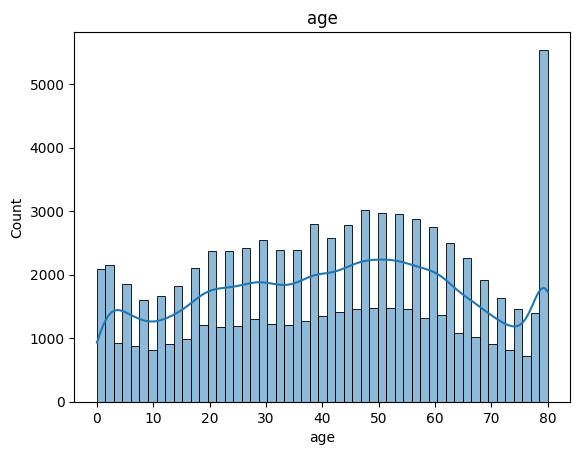

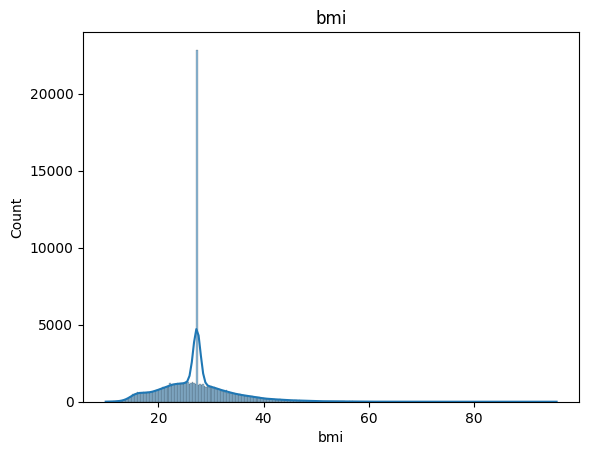

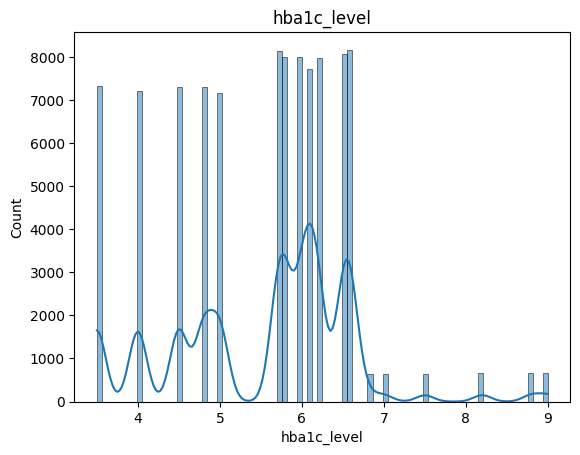

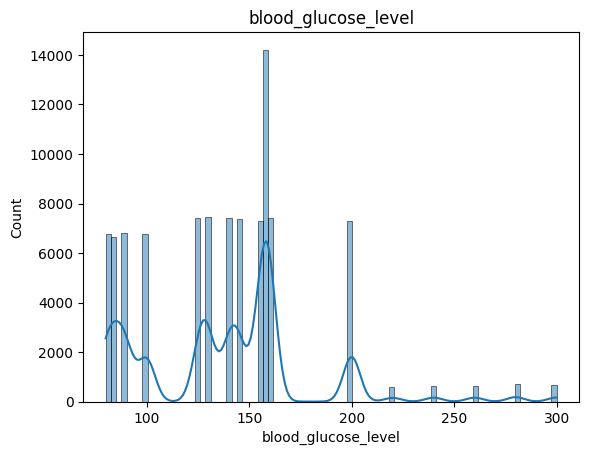

In [12]:
numerical_cols = ["age", "bmi", "hba1c_level", "blood_glucose_level"]

for col in numerical_cols:
    sns.histplot(df_diabetes[col], kde=True)
    plt.title(col)
    plt.show()

Age has a spike towards the end of the spectrum but this could very well be because of the massive impact that age has on diagnosis of diabetes, hence we will leave it that way.

BMI, however, has few values that look out of the scope of a reasonable medical context. It will be beneficial to our model to cap the BMI to something like 60 which is more reasonable.

In [13]:
count = len(df_diabetes[df_diabetes["bmi"] > 60])
df_diabetes = df_diabetes[df_diabetes["bmi"] <= 60]
print(f"Deleted {count} rows.")

Deleted 115 rows.


Hemoglobin A1c level looks reasonable. We will leave it as is.<br>
Blood glucose level, while highly right skewed, looks reasonable from the context that most patients in the dataset have diabetes.

Performing final checks and saving the cleaned dataset.

In [14]:
df_diabetes.info()

<class 'pandas.DataFrame'>
Index: 96031 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               96031 non-null  category
 1   age                  96031 non-null  int64   
 2   hypertension         96031 non-null  int64   
 3   heart_disease        96031 non-null  int64   
 4   smoking_history      96031 non-null  category
 5   bmi                  96031 non-null  float64 
 6   hba1c_level          96031 non-null  float64 
 7   blood_glucose_level  96031 non-null  int64   
 8   diabetes             96031 non-null  int64   
dtypes: category(2), float64(2), int64(5)
memory usage: 6.0 MB


In [15]:
df_diabetes.describe()

,age,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,diabetes
count,96031.000000,96031.000000,96031.000000,96031.000000,96031.000000,96031.000000,96031.00000
mean,41.780644,0.077475,0.040778,27.274327,5.532048,138.197884,0.08794
std,22.490013,0.267345,0.197778,6.627881,1.072818,40.885744,0.28321
min,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.00000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.00000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.00000
75%,59.000000,0.000000,0.000000,29.830000,6.200000,159.000000,0.00000
max,80.000000,1.000000,1.000000,60.000000,9.000000,300.000000,1.00000


In [16]:
diabetes_processed_path = root / "data" / "processed" / "diabetes.csv"
df_diabetes.to_csv(diabetes_processed_path)

### 2.2 Hypertension dataset

Inspecting the dataset

In [17]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB


**"has_hypertension" is the target variable**

In [18]:
df_hypertension.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [19]:
df_hypertension.describe()

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [20]:
df_hypertension.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

Standardizing column names

In [21]:
df_hypertension.columns = df_hypertension.columns.str.lower()
df_hypertension.columns

Index(['age', 'salt_intake', 'stress_score', 'bp_history', 'sleep_duration',
       'bmi', 'medication', 'family_history', 'exercise_level',
       'smoking_status', 'has_hypertension'],
      dtype='str')

Removing duplicates if any

In [22]:
df_hypertension.duplicated().sum()

np.int64(0)

Converting columns to categorical columns for efficiency 

In [23]:
categorical_cols = [
    "bp_history", "medication", "family_history",
    "exercise_level", "smoking_status", "has_hypertension"
]

for col in categorical_cols:
    df_hypertension[col] = df_hypertension[col].astype("category")

Looking at the earlier inspection of the dataset, we can see that only medication has null values which are most likely values showing an empty string because the patient does not take medication. Hence we can replace the empty values with a value like "None" indicating that the patient takes no medication.

In [24]:
df_hypertension["medication"] = df_hypertension["medication"].cat.add_categories(["None"])
df_hypertension["medication"] = df_hypertension["medication"].fillna("None")
df_hypertension.isnull().sum()

age                 0
salt_intake         0
stress_score        0
bp_history          0
sleep_duration      0
bmi                 0
medication          0
family_history      0
exercise_level      0
smoking_status      0
has_hypertension    0
dtype: int64

Now, lets look at handling outliers.

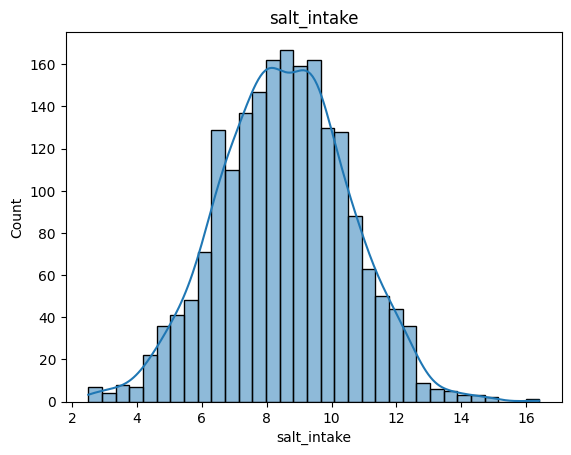

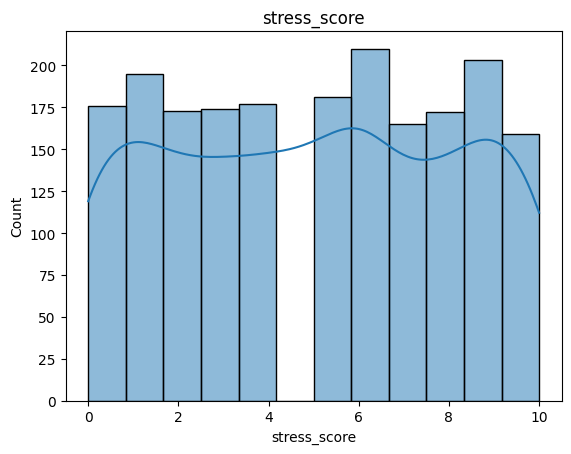

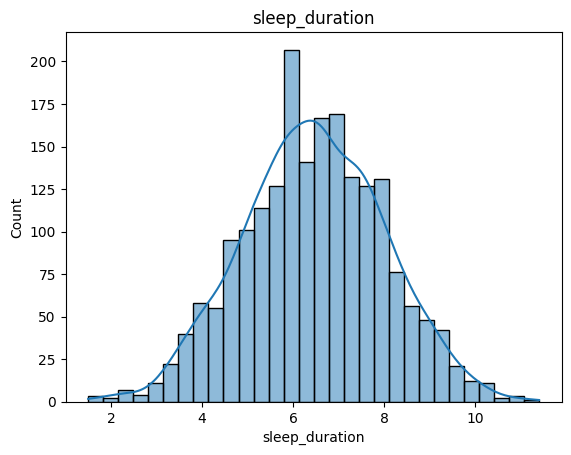

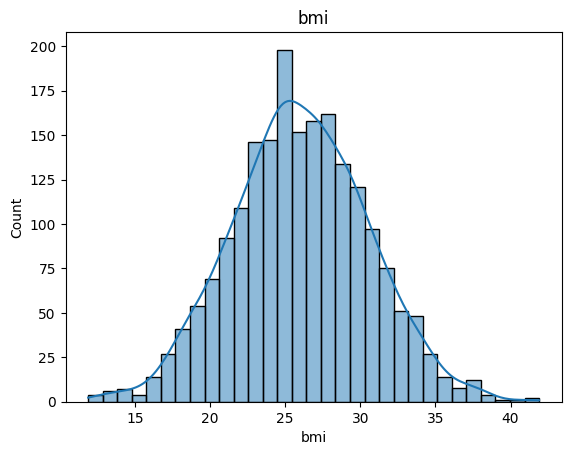

In [25]:
numerical_cols = ["salt_intake", "stress_score", "sleep_duration", "bmi"]

for col in numerical_cols:
    sns.histplot(df_hypertension[col], kde=True)
    plt.title(col)
    plt.show()

All the values look reasonable from a medical standpoint, hence no further action is required.

Final checks and saving the processed dataset

In [26]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1985 non-null   int64   
 1   salt_intake       1985 non-null   float64 
 2   stress_score      1985 non-null   int64   
 3   bp_history        1985 non-null   category
 4   sleep_duration    1985 non-null   float64 
 5   bmi               1985 non-null   float64 
 6   medication        1985 non-null   category
 7   family_history    1985 non-null   category
 8   exercise_level    1985 non-null   category
 9   smoking_status    1985 non-null   category
 10  has_hypertension  1985 non-null   category
dtypes: category(6), float64(3), int64(2)
memory usage: 89.7 KB


In [27]:
df_hypertension.describe()

,age,salt_intake,stress_score,sleep_duration,bmi
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000
mean,50.341058,8.531688,4.979345,6.452242,26.015315
std,19.442042,1.994907,3.142303,1.542207,4.512857
min,18.000000,2.500000,0.000000,1.500000,11.900000
25%,34.000000,7.200000,2.000000,5.400000,23.000000
50%,50.000000,8.500000,5.000000,6.500000,25.900000
75%,67.000000,9.900000,8.000000,7.500000,29.100000
max,84.000000,16.400000,10.000000,11.400000,41.900000


In [28]:
hypertension_processed_path = root / "data" / "processed" / "hypertension.csv"
df_hypertension.to_csv(hypertension_processed_path)

### 2.3 Heart disease dataset

Inspecting the dataset.

In [29]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

**"Heart Disease Status" is the target variable**

In [30]:
df_heart_disease.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [31]:
df_heart_disease.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [32]:
df_heart_disease.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

Standardizing column names

In [33]:
df_heart_disease.columns = (
    df_heart_disease.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)
df_heart_disease.columns

Index(['age', 'gender', 'blood_pressure', 'cholesterol_level',
       'exercise_habits', 'smoking', 'family_heart_disease', 'diabetes', 'bmi',
       'high_blood_pressure', 'low_hdl_cholesterol', 'high_ldl_cholesterol',
       'alcohol_consumption', 'stress_level', 'sleep_hours',
       'sugar_consumption', 'triglyceride_level', 'fasting_blood_sugar',
       'crp_level', 'homocysteine_level', 'heart_disease_status'],
      dtype='str')

Removing duplicates if any

In [34]:
df_heart_disease.duplicated().sum()

np.int64(0)

A lot of the columns can be stored as the category dtype, hence increasing efficiency.

In [35]:
categorical_cols = [
    "gender", "exercise_habits", "smoking", "family_heart_disease",
    "diabetes", "high_blood_pressure", "low_hdl_cholesterol", "high_ldl_cholesterol",
    "alcohol_consumption", "stress_level", "sugar_consumption", "heart_disease_status"
]

for col in categorical_cols:
    df_heart_disease[col] = df_heart_disease[col].astype("category")

Handling missing values

In [36]:
df_heart_disease["alcohol_consumption"].unique()

['High', 'Medium', 'Low', NaN]
Categories (3, str): ['High', 'Low', 'Medium']

There is an abnormally high amount of missing values in the alcohol consumption column of the dataset. While this may look like unentered values, upon taking a closer look at the data entered into this field, we can see that the null values indicate that the patient does not consume any alcohol. Hence we can give it a value, say, "None" to keep the data consistent. This is a form of constant imputation.

In [37]:
df_heart_disease["alcohol_consumption"] = df_heart_disease["alcohol_consumption"].cat.add_categories(["None"])
df_heart_disease["alcohol_consumption"] = df_heart_disease["alcohol_consumption"].fillna("None")
df_heart_disease["alcohol_consumption"].unique()

['High', 'Medium', 'Low', 'None']
Categories (4, str): ['High', 'Low', 'Medium', 'None']

For the remaining columns with null values, since the amount of null values is low (0.2% to 0.3%), we can impute those values using:
* Median imputation for numerical columns
* Mode imputation for categorical columns.

Median imputation

In [38]:
numerical_cols = [
    "age", "blood_pressure", "cholesterol_level", "bmi",
    "sleep_hours", "triglyceride_level",
    "fasting_blood_sugar", "crp_level", "homocysteine_level"
]

for col in numerical_cols:
    df_heart_disease[col] = df_heart_disease[col].fillna(df_heart_disease[col].median())

Mode imputation (we don't want the target variable to be affected)

In [39]:
for col in categorical_cols:
    if col == "heart_disease_status":
        continue

    df_heart_disease[col] = df_heart_disease[col].fillna(df_heart_disease[col].mode()[0])

In [40]:
df_heart_disease.isnull().sum()

age                     0
gender                  0
blood_pressure          0
cholesterol_level       0
exercise_habits         0
smoking                 0
family_heart_disease    0
diabetes                0
bmi                     0
high_blood_pressure     0
low_hdl_cholesterol     0
high_ldl_cholesterol    0
alcohol_consumption     0
stress_level            0
sleep_hours             0
sugar_consumption       0
triglyceride_level      0
fasting_blood_sugar     0
crp_level               0
homocysteine_level      0
heart_disease_status    0
dtype: int64

Handling outliers

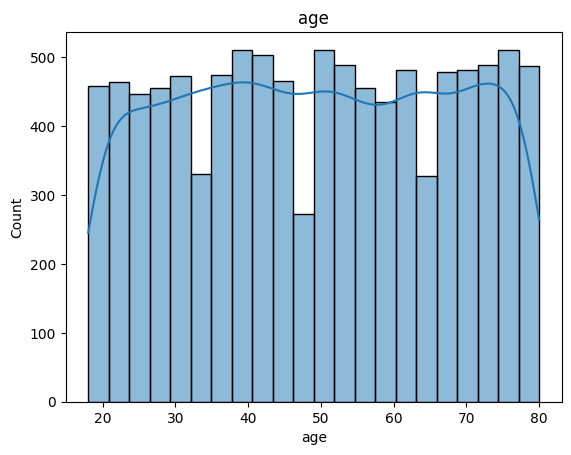

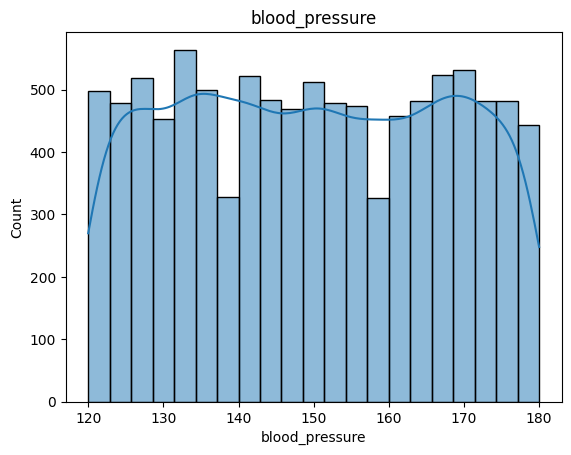

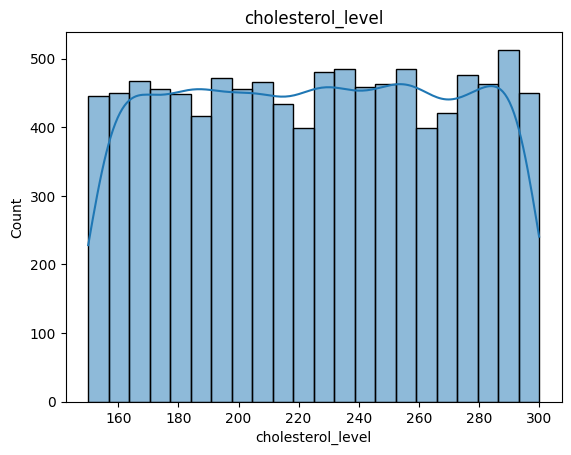

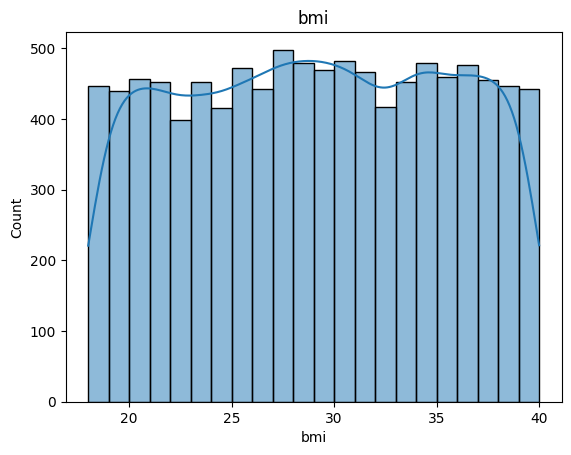

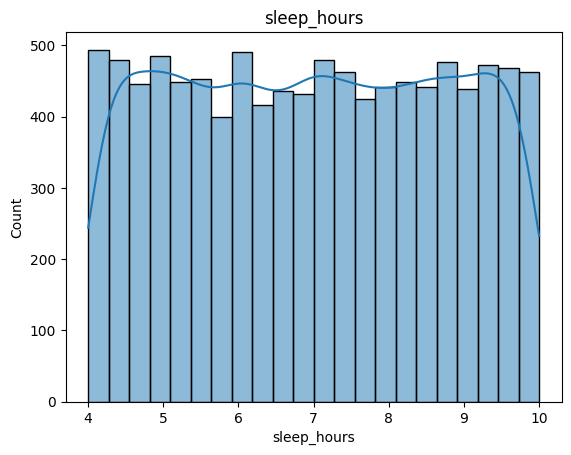

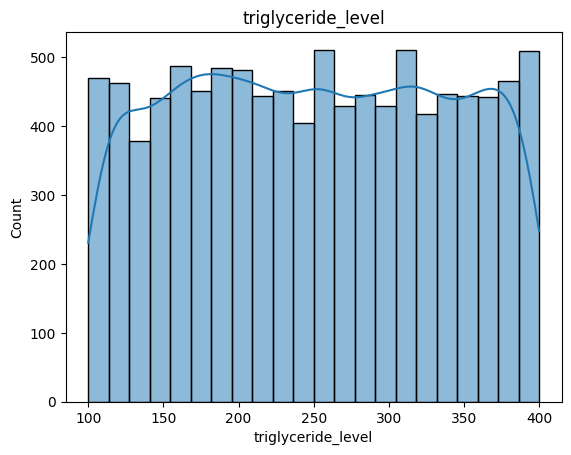

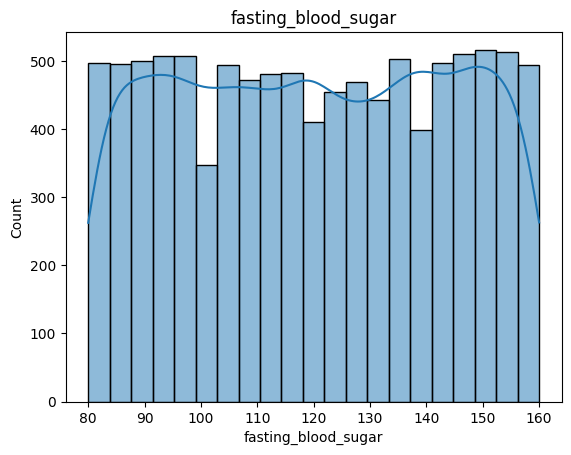

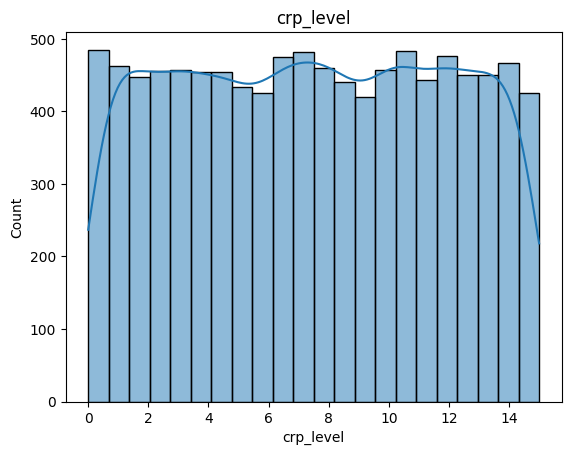

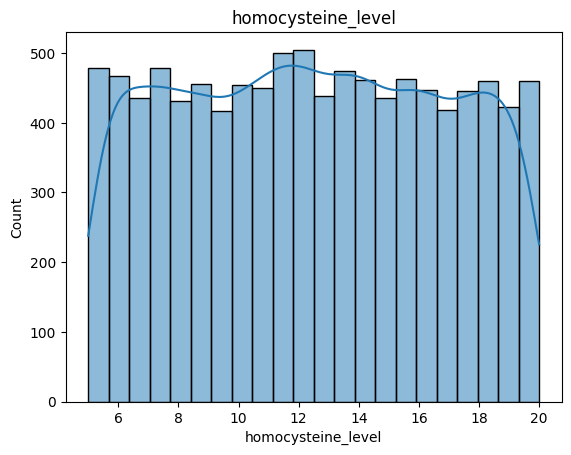

In [53]:
for col in numerical_cols:
    sns.histplot(df_heart_disease[col], kde=True)
    plt.title(col)
    plt.show()

From the above graphs we can see that all the features follow a proper distribution and no real outliers are present. Hence we will keep all of them as is.

Final verification and saving the dataset

In [54]:
df_heart_disease.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   10000 non-null  float64 
 1   gender                10000 non-null  category
 2   blood_pressure        10000 non-null  float64 
 3   cholesterol_level     10000 non-null  float64 
 4   exercise_habits       10000 non-null  category
 5   smoking               10000 non-null  category
 6   family_heart_disease  10000 non-null  category
 7   diabetes              10000 non-null  category
 8   bmi                   10000 non-null  float64 
 9   high_blood_pressure   10000 non-null  category
 10  low_hdl_cholesterol   10000 non-null  category
 11  high_ldl_cholesterol  10000 non-null  category
 12  alcohol_consumption   10000 non-null  category
 13  stress_level          10000 non-null  category
 14  sleep_hours           10000 non-null  float64 
 15  sugar_consumpt

In [55]:
df_heart_disease.describe()

,age,blood_pressure,cholesterol_level,bmi,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,homocysteine_level
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,49.295400,149.758200,225.427300,29.077274,6.991359,250.732500,120.141900,7.472200,12.456177
std,18.167574,17.556268,43.510401,6.300156,1.751002,86.953962,23.558053,4.334601,4.319100
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.668887,5.455288,176.000000,99.000000,3.681800,8.729771
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.509009,8.527938,326.000000,141.000000,11.244879,16.130968
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [56]:
heart_disease_processed_path = root / "data" / "processed" / "heart_disease.csv"
df_heart_disease.to_csv(heart_disease_processed_path)

## 3. Feature Engineering

### 3.1 Diabetes dataset